# Exploration: SeatGeek listings sample

Scratch work behind the dashboard and the README's Key Findings. Each section
below is a real step from the data-quality investigation, re-run here so the
reasoning can be checked cell by cell instead of taken on faith from the
README. `src/load_data.py`, `src/clean.py`, `src/join_tables.py`, and
`src/metrics.py` are the pipeline this notebook explores; nothing here is
imported back into them.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import matplotlib.pyplot as plt
import pandas as pd

from src.load_data import load_all
from src.clean import clean_all, find_premium_columns
from src.join_tables import build_all
from src.metrics import daily_new_events

pd.set_option("display.max_columns", 50)
raw = load_all()

Matplotlib is building the font cache; this may take a moment.


## 1. Raw dtypes and the [PREMIUM] mask

First question: what do the four raw tables actually look like before any
cleaning? In particular, which columns are locked behind SeatGeek's
`[PREMIUM]` mask, and are `performerIds` / `seats` really the only
`object`-dtype columns (everything else should already be a plain string,
bool, int, or datetime)?

In [2]:
for name, df in raw.items():
    masked = find_premium_columns(df)
    object_cols = df.columns[df.dtypes == object].tolist()
    print(f"{name:16s} {df.shape[0]:>6,} rows | premium: {masked or '-'} | object dtype: {object_cols or '-'}")

events            1,733 rows | premium: ['eventScore', 'popularityScore', 'listingCount', 'ticketCount', 'averagePrice', 'lowestPrice', 'highestPrice', 'medianPrice', 'lowestSgBasePrice'] | object dtype: ['performerIds']
event_listings   30,000 rows | premium: ['price', 'priceWithFees', 'fee', 'dealScore'] | object dtype: ['seats']
performers          257 rows | premium: ['heroImageUrl', 'bannerImageUrl'] | object dtype: -
venues              193 rows | premium: - | object dtype: -


Confirmed: `performerIds` (events) and `seats` (event_listings) are the only
`object` columns in the raw data — they hold numpy arrays, not strings. Every
other column, including ID-like strings such as `listingId`, is already a
proper pandas string dtype. This is why `src/clean.py`'s premium-column check
has to explicitly skip `object` columns: comparing a numpy array to the
string `"[PREMIUM]"` raises `ValueError: truth value of an array is
ambiguous`, not `False`.

In [3]:
tables = clean_all(raw)
for name, df in tables.items():
    dropped = set(raw[name].columns) - set(df.columns)
    print(f"{name:16s} {len(raw[name]):>6,} -> {len(df):>6,} rows | dropped: {sorted(dropped) or '-'}")

events            1,733 ->  1,732 rows | dropped: ['averagePrice', 'eventScore', 'highestPrice', 'listingCount', 'lowestPrice', 'lowestSgBasePrice', 'medianPrice', 'popularityScore', 'ticketCount']
event_listings   30,000 -> 30,000 rows | dropped: ['dealScore', 'fee', 'price', 'priceWithFees']
performers          257 ->    257 rows | dropped: ['bannerImageUrl', 'heroImageUrl']
venues              193 ->    193 rows | dropped: -


## 2. The events-listings join rate

The dashboard's overview banner says only 4,000 of 30,000 listings (13%)
match an events row. Where does that number come from, and is it evenly
spread or concentrated?

In [4]:
joined = build_all(tables)
listings, events = tables["event_listings"], tables["events"]

distinct_ids = listings["eventId"].nunique()
matched_ids = listings.loc[listings["eventId"].isin(events["eventId"]), "eventId"].nunique()
matched_rows = len(joined["matched_listings"])

print(f"distinct eventIds in listings: {distinct_ids}")
print(f"  matched to an events row:    {matched_ids}")
print(f"  unmatched:                   {distinct_ids - matched_ids}")
print(f"matched listing rows:          {matched_rows:,} of {len(listings):,} ({matched_rows / len(listings):.1%})")
print(f"matched events are all type:   {joined['matched_listings']['type'].unique().tolist()}")

distinct eventIds in listings: 555
  matched to an events row:    32
  unmatched:                   523
matched listing rows:          4,000 of 30,000 (13.3%)
matched events are all type:   ['nba']


Only 32 of 555 distinct `eventId`s in the listings table have a matching
events row — and every one of those 32 is an NBA game. That's a striking
enough pattern to trace further: is it random, or does it have a cause?

In [5]:
unmatched = listings.loc[~listings["eventId"].isin(events["eventId"]), "eventId"].drop_duplicates().sort_values()
print(f"unmatched eventId range: {unmatched.min()} - {unmatched.max()}")
print(f"events table eventId range: {events['eventId'].min()} - {events['eventId'].max()}")

# how many unmatched IDs actually fall *inside* the events table's own ID range?
in_range = unmatched.between(events["eventId"].min(), events["eventId"].max())
print(f"unmatched IDs inside the events table's own ID range: {in_range.sum()} of {len(unmatched)}")

# the specific block traced during the investigation
block = unmatched[(unmatched >= 18_376_000) & (unmatched <= 18_379_100)]
print(f"unmatched IDs in the 18,376,000-18,379,100 block: {len(block)} ({len(block) / len(unmatched):.0%} of all unmatched)")
print(f"events table rows in that same block: {events['eventId'].between(18_376_000, 18_379_100).sum()}")

unmatched eventId range: 17565118 - 18499772
events table eventId range: 17691307 - 18514381
unmatched IDs inside the events table's own ID range: 522 of 523
unmatched IDs in the 18,376,000-18,379,100 block: 377 (72% of all unmatched)
events table rows in that same block: 0


So it's not that these IDs are simply outside the events table's range —
522 of 523 unmatched IDs fall *inside* it. Something specific happened in a
contiguous block of ~377 IDs. `daily_new_events` (used on the dashboard)
makes the cause visible directly: a spike on Aug 31 that lands exactly on
1,000, the same daily export cap that produced the events table's rows in
the first place.

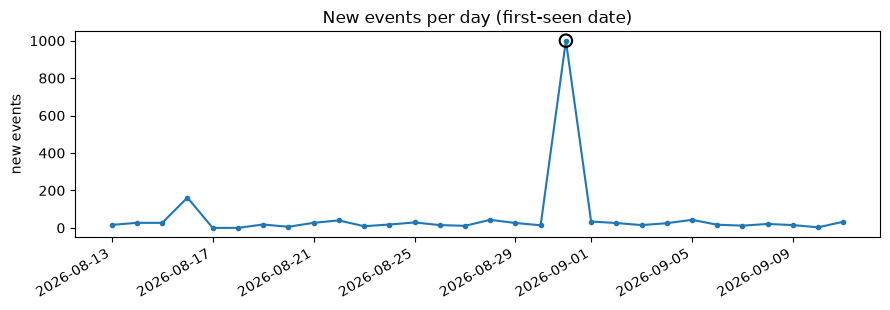

                      day  newEvents
2026-08-31 00:00:00+00:00       1000


In [6]:
daily = daily_new_events(events)

fig, ax = plt.subplots(figsize=(9, 3.2))
ax.plot(daily["day"], daily["newEvents"], marker="o", markersize=3)
cap = daily[daily["hitExportCap"]]
ax.scatter(cap["day"], cap["newEvents"], s=80, facecolors="none", edgecolors="black", linewidths=1.5, zorder=3)
ax.set_title("New events per day (first-seen date)")
ax.set_ylabel("new events")
fig.autofmt_xdate()
fig.tight_layout()
plt.show()

print(daily.loc[daily["hitExportCap"], ["day", "newEvents"]].to_string(index=False))

Aug 31 hits exactly 1,000 new events — the same "up to 1,000 rows/day" cap
documented in `data/raw/DATASET_README.md` for the events export. A batch
export that size, mid-cap, plausibly cuts off before every event in that
day's block got written, which is consistent with the 377-ID gap found above.
This isn't provable from the sample alone, but it's the simplest explanation
that fits every number so far.

## 3. Seats: null vs. empty array

`seat_type_share` on the dashboard reports 15.1% of listings have assigned
seats, versus the dataset's documented 23% fill rate for the full 98.7M-row
dataset. Before trusting that gap as "just sampling variance" rather than a
bug in `has_assigned_seats()`, it's worth checking directly: are GA listings
truly empty arrays, or could some be nulls that `.str.len()` mishandles?

In [7]:
seats = tables["event_listings"]["seats"]
lengths = seats.str.len()

print(f"null:        {seats.isna().sum():,}")
print(f"empty array: {(lengths == 0).sum():,}")
print(f"non-empty:   {(lengths > 0).sum():,}  ({(lengths > 0).mean():.1%})")
print()
print("a non-empty example:", seats[lengths > 0].iloc[0])

null:        0
empty array: 25,462
non-empty:   4,538  (15.1%)

a non-empty example: ['9' '10' '11']


Confirmed: every GA/unassigned listing has an empty array, never a null. The
15.1% figure is not a bug in how nulls are handled — `has_assigned_seats()`'s
behavior is correct on this data. The gap from the dataset's stated 23% is a
real property of this 30-day sample, most likely because the sample draws
only 555 distinct events total, so day-to-day composition swings hard. (This
was cross-checked against the raw CSV copies too, not shown here since it
just reproduces the same counts.)

## Summary

These four threads are the ones that ended up in the README's Key Findings:
market structure (concentrated, mostly digital), deal quality being roughly
marketplace-agnostic, the join-rate root cause traced above, and this
sample's divergence from the full dataset's published baselines. See
`README.md` for the numbers as reported on the dashboard.